## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

# display settings
pd.set_option("display.max_columns",None)
pd.set_option("display.width",1000)

print("All libraries imported successfully!!")


All libraries imported successfully!!


---

## Load Files

In [2]:
PATH = r'C:\Users\chand\OneDrive\Desktop\Fifa_Datasets\\'

results=pd.read_csv(PATH+"results.csv")
shootouts=pd.read_csv(PATH+"shootouts.csv")
goalscorers=pd.read_csv(PATH+"goalscorers.csv")
former=pd.read_csv(PATH+"former_names.csv")

print(f"results:{results.shape}")
print(f"shootouts:{shootouts.shape}")
print(f"goalscorers:{goalscorers.shape}")
print(f"former:{former.shape}")

results:(49287, 9)
shootouts:(675, 5)
goalscorers:(47601, 8)
former:(36, 4)


---

In [3]:
results.head()
results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [4]:
# results Dataset
print("===First Row===")
print(results.head())
print("\n==column info==")
print(results.info())
print("\n===Missing Values===")
print(results.isnull().sum())

===First Row===
         date home_team away_team  home_score  away_score tournament     city   country  neutral
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow  Scotland    False
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   England    False
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow  Scotland    False
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   England    False
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow  Scotland    False

==column info==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null

---

## Clean the Data

In [5]:
# step1-Drop rows where score is missing 
df=results.dropna(subset=['home_score','away_score']).copy()
print(f"Rows after dropping nulls:{len(df)}")
print(f"Rows before cleaning : {len(results)}")
print(f"Rows after cleaning  : {len(df)}")
print(f"Rows dropped         : {len(results) - len(df)}")

Rows after dropping nulls:49215
Rows before cleaning : 49287
Rows after cleaning  : 49215
Rows dropped         : 72


In [6]:
# step2 convert Date to datetime
df['date']=pd.to_datetime(df['date'],format='mixed')
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month

print("Date conversion done!")
print(f"Earliest match: {df['date'].min()}")
print(f"Latest match:   {df['date'].max()}")

Date conversion done!
Earliest match: 1872-11-30 00:00:00
Latest match:   2026-10-01 00:00:00


In [7]:
# step 3 - Convert neutral (True/False into 1/0)
df['neutral']=df['neutral'].astype(int)

In [8]:
# step 4 - create target column
def get_result(row):
    if row['home_score']>row['away_score']: return 'Win'
    elif row['home_score']<row['away_score']:return 'Loss'
    else:
        return 'Draw'

In [9]:
df['result']=df.apply(get_result,axis=1)

In [10]:
df['result']

0        Draw
1         Win
2         Win
3        Draw
4         Win
         ... 
49210    Loss
49211    Draw
49212     Win
49213     Win
49214     Win
Name: result, Length: 49215, dtype: object

In [11]:
#step 5 Verify
print("\n ===Result distribution===")
counts=df['result'].value_counts()
total=len(df)
for label,count in counts.items():
    pct=count/total*100
    bar = '█' * int(pct / 2)
    print(f"  {label:<5} {count:>6}  ({pct:.1f}%)  {bar}")

print("\n ===Sample rows===")
df[['date','home_team','away_team','home_score','away_score','result']].head(8)


 ===Result distribution===
  Win    24106  (49.0%)  ████████████████████████
  Loss   13912  (28.3%)  ██████████████
  Draw   11197  (22.8%)  ███████████

 ===Sample rows===


,date,home_team,away_team,home_score,away_score,result
0,1872-11-30,Scotland,England,0.0,0.0,Draw
1,1873-03-08,England,Scotland,4.0,2.0,Win
2,1874-03-07,Scotland,England,2.0,1.0,Win
3,1875-03-06,England,Scotland,2.0,2.0,Draw
4,1876-03-04,Scotland,England,3.0,0.0,Win
5,1876-03-25,Scotland,Wales,4.0,0.0,Win
6,1877-03-03,England,Scotland,1.0,3.0,Loss
7,1877-03-05,Wales,Scotland,0.0,2.0,Loss


---

## Data Visulisation

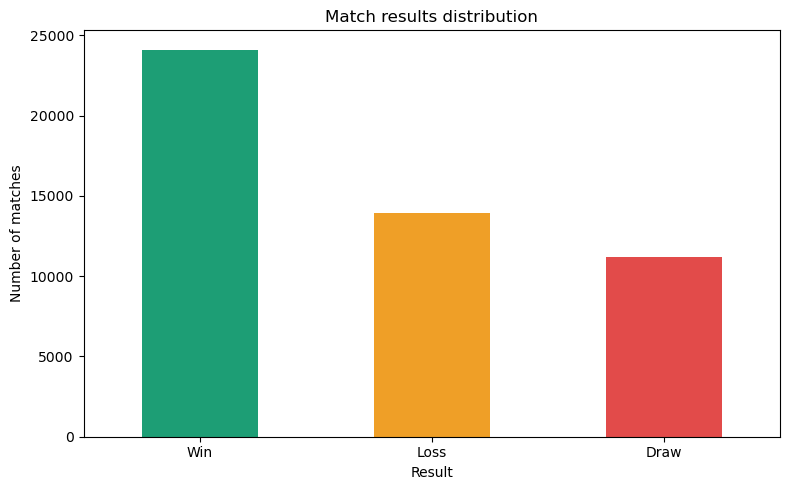

In [12]:
# CHART 1 — How many wins, draws and losses?
df['result'].value_counts().plot(
    kind='bar',
    color=['#1D9E75', '#EF9F27', '#E24B4A'],
    figsize=(8, 5)
)
plt.title('Match results distribution')
plt.xlabel('Result')
plt.ylabel('Number of matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

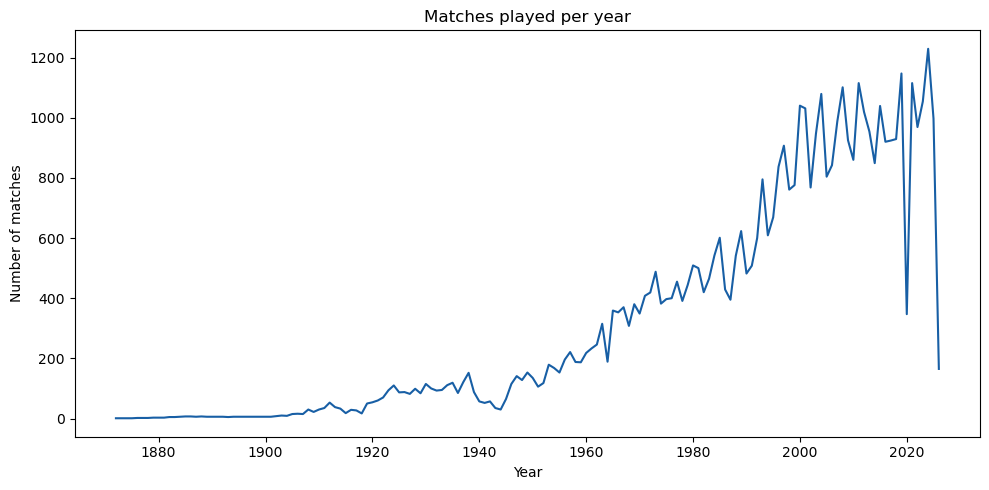

In [13]:
# CHART 2 — How has football grown over the years?
df.groupby('year').size().plot(
    kind='line',
    color='#185FA5',
    figsize=(10, 5)
)
plt.title('Matches played per year')
plt.xlabel('Year')
plt.ylabel('Number of matches')
plt.tight_layout()
plt.show()

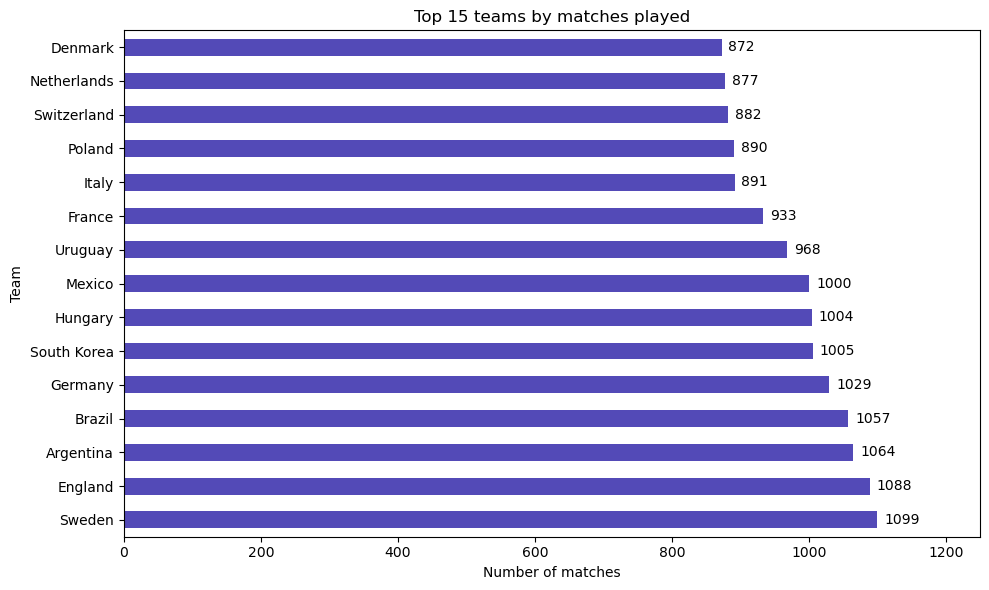

In [14]:
# CHART 3 — Which teams have played the most matches?
top_teams = pd.concat([df['home_team'], df['away_team']]).value_counts().head(15)

top_teams.plot(
    kind='barh',
    color='#534AB7',
    figsize=(10, 6)
)

# Add numbers beside each bar
for i, (team, count) in enumerate(top_teams.items()):
    plt.text(count + 10, i, str(count), va='center', fontsize=10)

plt.title('Top 15 teams by matches played')
plt.xlabel('Number of matches')
plt.ylabel('Team')
plt.xlim(0, top_teams.max() + 150)
plt.tight_layout()
plt.show()

---

## FIFA Ranking for all 48 World Cup 2026 team

In [15]:
fifa_rankings = {
    # Group A
    'Mexico': 15,
    'South Africa': 61,
    'South Korea': 25,
    'Czech Republic': 41,

    # Group B
    'Canada': 30,
    'Bosnia and Herzegovina': 65,
    'Qatar': 56,
    'Switzerland': 19,

    # Group C
    'Brazil': 6,
    'Morocco': 8,
    'Haiti': 83,
    'Scotland': 39,

    # Group D
    'United States': 16,
    'Paraguay': 40,
    'Australia': 27,
    'Turkey': 22,

    # Group E
    'Germany': 10,
    'Curaçao': 82,
    'Ivory Coast': 34,
    'Ecuador': 23,

    # Group F
    'Netherlands': 7,
    'Japan': 18,
    'Sweden': 38,
    'Tunisia': 44,

    # Group G
    'Belgium': 9,
    'Egypt': 29,
    'Iran': 21,
    'New Zealand': 85,

    # Group H
    'Spain': 2,
    'Cape Verde': 69,
    'Saudi Arabia': 60,
    'Uruguay': 17,

    # Group I
    'France': 1,
    'Senegal': 14,
    'Iraq': 57,
    'Norway': 31,

    # Group J
    'Argentina': 3,
    'Algeria': 28,
    'Austria': 24,
    'Jordan': 63,

    # Group K
    'Portugal': 5,
    'DR Congo': 46,
    'Uzbekistan': 50,
    'Colombia': 13,

    # Group L
    'England': 4,
    'Croatia': 11,
    'Ghana': 74,
    'Panama': 33,
}

# world cup 2026 grps
wc_groups = {
    'Group A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'Group B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'Group C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'Group D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'Group E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'Group F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'Group G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'Group H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'Group I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'Group J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'Group K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'Group L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

# Convert rankings to DataFrame
rankings_df = pd.DataFrame(
    list(fifa_rankings.items()),
    columns=['team', 'fifa_ranking']
)

print(f"Total teams loaded: {len(rankings_df)}")
print(f"Total groups: {len(wc_groups)}")
print("\nAll 48 teams sorted by ranking:")
print(rankings_df.sort_values('fifa_ranking').to_string(index=False))

Total teams loaded: 48
Total groups: 12

All 48 teams sorted by ranking:
                  team  fifa_ranking
                France             1
                 Spain             2
             Argentina             3
               England             4
              Portugal             5
                Brazil             6
           Netherlands             7
               Morocco             8
               Belgium             9
               Germany            10
               Croatia            11
              Colombia            13
               Senegal            14
                Mexico            15
         United States            16
               Uruguay            17
                 Japan            18
           Switzerland            19
                  Iran            21
                Turkey            22
               Ecuador            23
               Austria            24
           South Korea            25
             Australia            27
  

---

## Filter only World Cup 2026 teams

In [16]:
wc_teams = list(fifa_rankings.keys())

# Keep only matches where both teams are in the World Cup
df_wc = df[
    (df['home_team'].isin(wc_teams)) &
    (df['away_team'].isin(wc_teams))
].copy()

print(f"Total matches before filter : {len(df)}")
print(f"Matches after filter        : {len(df_wc)}")
print(f"Matches removed             : {len(df) - len(df_wc)}")

print("\n=== Result distribution after filter ===")
counts = df_wc['result'].value_counts()
total = len(df_wc)
for label, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<5} {count:>6}  ({pct:.1f}%)  {bar}")

Total matches before filter : 49215
Matches after filter        : 7501
Matches removed             : 41714

=== Result distribution after filter ===
  Win     3479  (46.4%)  ███████████████████████
  Loss    2124  (28.3%)  ██████████████
  Draw    1898  (25.3%)  ████████████


In [17]:
# This code adds FIFA rankings to your match dataset and calculates 
# the ranking difference between teams.

# Merge FIFA rankings into df_wc
df_wc = df_wc.merge(
    rankings_df.rename(columns={'team': 'home_team', 'fifa_ranking': 'home_ranking'}),
    on='home_team', how='left'
)

df_wc = df_wc.merge(
    rankings_df.rename(columns={'team': 'away_team', 'fifa_ranking': 'away_ranking'}),
    on='away_team', how='left'
)

# Ranking difference — how big is the gap between the two teams
df_wc['ranking_difference'] = df_wc['away_ranking'] - df_wc['home_ranking']

print(f"Shape: {df_wc.shape}")
print("\nSample with rankings:")
df_wc[['home_team','away_team','home_ranking','away_ranking','ranking_difference','result']].head(8)

Shape: (7501, 15)

Sample with rankings:


,home_team,away_team,home_ranking,away_ranking,ranking_difference,result
0,Scotland,England,39,4,-35,Draw
1,England,Scotland,4,39,35,Win
2,Scotland,England,39,4,-35,Win
3,England,Scotland,4,39,35,Draw
4,Scotland,England,39,4,-35,Win
5,England,Scotland,4,39,35,Loss
6,Scotland,England,39,4,-35,Win
7,England,Scotland,4,39,35,Win


# FIFA Ranking Merge Explanation

## Before Merge

`df_wc` originally contains match information like:

| home_team | away_team | result |
|---|---|---|
| Brazil | Argentina | Win |
| France | Germany | Draw |



## After First Merge

This merge adds:

`home_ranking`

| home_team | away_team | result | home_ranking |
|---|---|---|---|
| Brazil | Argentina | Win | 1 |
| France | Germany | Draw | 2 |

Meaning:
- Brazil FIFA rank = 1
- France FIFA rank = 2



## After Second Merge

This merge adds:

 `away_ranking`

| home_team | away_team | result | home_ranking | away_ranking |
|---|---|---|---|---|
| Brazil | Argentina | Win | 1 | 3 |
| France | Germany | Draw | 2 | 10 |

Meaning:
- Argentina FIFA rank = 3
- Germany FIFA rank = 10



## After Ranking Difference

This line adds:

 `ranking_difference`

Formula:

```python
away_ranking - home_ranking

 Negative difference means home team is BETTER ranked than away team
 Positive difference means away team is BETTER ranked

In [18]:
df_wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1873,3,Win,4,39,35
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1875,3,Draw,4,39,35
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35


In [19]:
# Quick check of all columns
print(df_wc.columns.tolist())
print(f"\nShape: {df_wc.shape}")
print(f"Date range: {df_wc['date'].min()} to {df_wc['date'].max()}")
print(f"\nMissing values:")
print(df_wc.isnull().sum())

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'year', 'month', 'result', 'home_ranking', 'away_ranking', 'ranking_difference']

Shape: (7501, 15)
Date range: 1872-11-30 00:00:00 to 2026-10-01 00:00:00

Missing values:
date                  0
home_team             0
away_team             0
home_score            0
away_score            0
tournament            0
city                  0
country               0
neutral               0
year                  0
month                 0
result                0
home_ranking          0
away_ranking          0
ranking_difference    0
dtype: int64


---

## feature engineering

In [20]:
# feature 1- Tournament Importance
def get_tournament_importance(tournament):
    tournament = tournament.lower()
    if 'fifa world cup' in tournament and 'qualification' not in tournament:
        return 5
    elif 'qualification' in tournament:
        return 4
    elif any(x in tournament for x in ['copa america', 'uefa euro', 'africa cup', 'asian cup', 'gold cup']):
        return 3
    elif any(x in tournament for x in ['nations league', 'confederation']):
        return 2
    else:
        return 1  # Friendly or minor tournament

df_wc['tournament_importance'] = df_wc['tournament'].apply(get_tournament_importance)

# Verify
print("Tournament importance distribution:")
print(df_wc['tournament_importance'].value_counts().sort_index())
print("\nSample:")
df_wc[['tournament','tournament_importance']].drop_duplicates().sort_values('tournament_importance', ascending=False).head(30)

Tournament importance distribution:
tournament_importance
1    4993
2     216
3     326
4    1507
5     459
Name: count, dtype: int64

Sample:


,tournament,tournament_importance
536,FIFA World Cup,5
1377,UEFA Euro qualification,4
1766,AFC Asian Cup qualification,4
624,FIFA World Cup qualification,4
4272,Gold Cup qualification,4
3091,Arab Cup qualification,4
1742,Copa América qualification,4
1747,CONCACAF Championship qualification,4
1582,African Cup of Nations qualification,4
2017,UEFA Euro,3


In [21]:
#4,993 out of 7,501 matches are friendlies(1 means that is friendly match less importance). 
#That's 66% of our data

#459 out of 7,501 matches are FIFA WORLD CUP Matches

In [22]:
df_wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1873,3,Win,4,39,35,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35,1
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1875,3,Draw,4,39,35,1
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35,1


---

In [23]:
# feature 2 - Team Form (win rate last 5)
def get_team_form(team, date, df, n=5):
    # Get all past matches for this team before this date
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date)
    ].sort_values('date').tail(n)

    if len(past) == 0:
        return 0.5  # No history — assume 50/50

    wins = 0
    for _, row in past.iterrows():
        if row['home_team'] == team and row['result'] == 'Win':
            wins += 1
        elif row['away_team'] == team and row['result'] == 'Loss':
            wins += 1  # Loss means away team won

    return wins / len(past)

# home_form_5 and away_form_5 = win rate in last 5 matches
# Apply for last 5 matches
print("Calculating home team form last 5...")
df_wc['home_form_5'] = df_wc.apply(
    lambda row: get_team_form(row['home_team'], row['date'], df_wc, 5), axis=1
)

print("Calculating away team form last 5...")
df_wc['away_form_5'] = df_wc.apply(
    lambda row: get_team_form(row['away_team'], row['date'], df_wc, 5), axis=1
)

print()
print(df_wc[['home_team','away_team','home_form_5','away_form_5','result']].head(8))

Calculating home team form last 5...
Calculating away team form last 5...

  home_team away_team  home_form_5  away_form_5 result
0  Scotland   England     0.500000     0.500000   Draw
1   England  Scotland     0.000000     0.000000    Win
2  Scotland   England     0.000000     0.500000    Win
3   England  Scotland     0.333333     0.333333   Draw
4  Scotland   England     0.250000     0.250000    Win
5   England  Scotland     0.200000     0.400000   Loss
6  Scotland   England     0.600000     0.200000    Win
7   England  Scotland     0.000000     0.800000    Win


In [24]:
df_wc.head() 

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance,home_form_5,away_form_5
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1,0.500000,0.500000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1873,3,Win,4,39,35,1,0.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35,1,0.000000,0.500000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1875,3,Draw,4,39,35,1,0.333333,0.333333
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35,1,0.250000,0.250000


---

In [25]:
# Feature 3 - Team Form last 10 matches

print("Calculating home team form last 10...")
df_wc['home_form_10'] = df_wc.apply(
    lambda row: get_team_form(row['home_team'], row['date'], df_wc, 10), axis=1
)

print("Calculating away team form last 10...")
df_wc['away_form_10'] = df_wc.apply(
    lambda row: get_team_form(row['away_team'], row['date'], df_wc, 10), axis=1
)

print()
print(df_wc[['home_team','away_team','home_form_5','home_form_10','away_form_5','away_form_10','result']].head(10))


Calculating home team form last 10...
Calculating away team form last 10...

  home_team away_team  home_form_5  home_form_10  away_form_5  away_form_10 result
0  Scotland   England     0.500000      0.500000     0.500000      0.500000   Draw
1   England  Scotland     0.000000      0.000000     0.000000      0.000000    Win
2  Scotland   England     0.000000      0.000000     0.500000      0.500000    Win
3   England  Scotland     0.333333      0.333333     0.333333      0.333333   Draw
4  Scotland   England     0.250000      0.250000     0.250000      0.250000    Win
5   England  Scotland     0.200000      0.200000     0.400000      0.400000   Loss
6  Scotland   England     0.600000      0.500000     0.200000      0.166667    Win
7   England  Scotland     0.000000      0.142857     0.800000      0.571429    Win
8  Scotland   England     0.600000      0.500000     0.200000      0.250000    Win
9   England  Scotland     0.200000      0.222222     0.800000      0.555556   Loss


| Value | Meaning |
|---|---|
| 1.0 | Won ALL last 5/10 matches |
| 0.8 | Won 4 out of 5 |
| 0.5 | Won half — average team |
| 0.2 | Won only 1 out of 5 — bad form |
| 0.0 | Lost ALL last 5/10 matches |

In [26]:
df_wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance,home_form_5,away_form_5,home_form_10,away_form_10
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1,0.500000,0.500000,0.500000,0.500000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1873,3,Win,4,39,35,1,0.000000,0.000000,0.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35,1,0.000000,0.500000,0.000000,0.500000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1875,3,Draw,4,39,35,1,0.333333,0.333333,0.333333,0.333333
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35,1,0.250000,0.250000,0.250000,0.250000


In [27]:
#These form features are NOT head-to-head (H2H) records.
#They include matches against different teams also.

---

In [28]:
# Feature 4 - Goals scored and conceded avg (last 5)
def get_goals_avg(team, date, df, n=5, scored=True):
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date)
    ].sort_values('date').tail(n)

    if len(past) == 0:
        return 1.0  # average default

    goals = []
    for _, row in past.iterrows():
        if row['home_team'] == team:
            goals.append(row['home_score'] if scored else row['away_score'])
        else:
            goals.append(row['away_score'] if scored else row['home_score'])

    return sum(goals) / len(goals)

print("Calculating goals scored avg...")
df_wc['home_goals_scored_avg'] = df_wc.apply(
    lambda row: get_goals_avg(row['home_team'], row['date'], df_wc, 5, scored=True), axis=1
)
df_wc['away_goals_scored_avg'] = df_wc.apply(
    lambda row: get_goals_avg(row['away_team'], row['date'], df_wc, 5, scored=True), axis=1
)

print("Calculating goals conceded avg...")
df_wc['home_goals_conceded_avg'] = df_wc.apply(
    lambda row: get_goals_avg(row['home_team'], row['date'], df_wc, 5, scored=False), axis=1
)
df_wc['away_goals_conceded_avg'] = df_wc.apply(
    lambda row: get_goals_avg(row['away_team'], row['date'], df_wc, 5, scored=False), axis=1
)

print()
df_wc[['home_team','away_team','home_score','away_score','home_goals_scored_avg','home_goals_conceded_avg','away_goals_scored_avg','away_goals_conceded_avg','result']].head(8)

Calculating goals scored avg...
Calculating goals conceded avg...



,home_team,away_team,home_score,away_score,home_goals_scored_avg,home_goals_conceded_avg,away_goals_scored_avg,away_goals_conceded_avg,result
0,Scotland,England,0.0,0.0,1.000000,1.000000,1.000000,1.000000,Draw
1,England,Scotland,4.0,2.0,0.000000,0.000000,0.000000,0.000000,Win
2,Scotland,England,2.0,1.0,1.000000,2.000000,2.000000,1.000000,Win
3,England,Scotland,2.0,2.0,1.666667,1.333333,1.333333,1.666667,Draw
4,Scotland,England,3.0,0.0,1.500000,1.750000,1.750000,1.500000,Win
5,England,Scotland,1.0,3.0,1.400000,1.800000,1.800000,1.400000,Loss
6,Scotland,England,7.0,2.0,2.400000,1.600000,1.600000,2.400000,Win
7,England,Scotland,5.0,4.0,1.200000,3.400000,3.400000,1.200000,Win


| Parameter | Meaning |
|---|---|
| `team` | Team name |
| `date` | Current match date |
| `df` | Match dataframe |
| `n=5` | Check last 5 matches |
| `scored=True` | Calculate goals scored average |
| `scored=False` | Calculate goals conceded average |

In [29]:
df_wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance,home_form_5,away_form_5,home_form_10,away_form_10,home_goals_scored_avg,away_goals_scored_avg,home_goals_conceded_avg,away_goals_conceded_avg
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1,0.500000,0.500000,0.500000,0.500000,1.000000,1.000000,1.000000,1.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1873,3,Win,4,39,35,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35,1,0.000000,0.500000,0.000000,0.500000,1.000000,2.000000,2.000000,1.000000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1875,3,Draw,4,39,35,1,0.333333,0.333333,0.333333,0.333333,1.666667,1.333333,1.333333,1.666667
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35,1,0.250000,0.250000,0.250000,0.250000,1.500000,1.750000,1.750000,1.500000


---

In [30]:
# Feature 5 - Head to Head

def get_h2h_stats(home_team, away_team, date, df):
    # Get all past matches between these two specific teams
    h2h = df[
        (
            ((df['home_team'] == home_team) & (df['away_team'] == away_team)) |
            ((df['home_team'] == away_team) & (df['away_team'] == home_team))
        ) &
        (df['date'] < date)
    ]

    if len(h2h) == 0:
        return 0.5, 0.25, 0  # no history — neutral defaults

    total = len(h2h)
    home_wins = 0
    draws = 0

    for _, row in h2h.iterrows():
        if row['home_team'] == home_team and row['result'] == 'Win':
            home_wins += 1
        elif row['home_team'] == away_team and row['result'] == 'Loss':
            home_wins += 1  # home_team was away and won
        elif row['result'] == 'Draw':
            draws += 1

    return home_wins / total, draws / total, total


print("Calculating H2H features..")

h2h_results = df_wc.apply(
    lambda row: get_h2h_stats(
        row['home_team'], row['away_team'], row['date'], df_wc
    ), axis=1
)

df_wc['h2h_home_win_rate']  = h2h_results.apply(lambda x: x[0])
df_wc['h2h_draw_rate']      = h2h_results.apply(lambda x: x[1])
df_wc['h2h_total_matches']  = h2h_results.apply(lambda x: x[2])

print()
print(df_wc[['home_team','away_team','h2h_home_win_rate','h2h_draw_rate','h2h_total_matches','result']].head(10))

Calculating H2H features..

  home_team away_team  h2h_home_win_rate  h2h_draw_rate  h2h_total_matches result
0  Scotland   England           0.500000       0.250000                  0   Draw
1   England  Scotland           0.000000       1.000000                  1    Win
2  Scotland   England           0.000000       0.500000                  2    Win
3   England  Scotland           0.333333       0.333333                  3   Draw
4  Scotland   England           0.250000       0.500000                  4    Win
5   England  Scotland           0.200000       0.400000                  5   Loss
6  Scotland   England           0.500000       0.333333                  6    Win
7   England  Scotland           0.142857       0.285714                  7    Win
8  Scotland   England           0.500000       0.250000                  8    Win
9   England  Scotland           0.222222       0.222222                  9   Loss


| Feature | Meaning |
|---|---|
| `h2h_total_matches = 0` | Teams never played before |
| `h2h_home_win_rate = 0.5` | No history → assume 50/50 chance |
| `h2h_draw_rate = 0.25` | No history → default draw probability |
| `Result = Draw` | Current match ended in draw |

In [31]:
df_wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance,home_form_5,away_form_5,home_form_10,away_form_10,home_goals_scored_avg,away_goals_scored_avg,home_goals_conceded_avg,away_goals_conceded_avg,h2h_home_win_rate,h2h_draw_rate,h2h_total_matches
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1,0.500000,0.500000,0.500000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,0.250000,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1873,3,Win,4,39,35,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35,1,0.000000,0.500000,0.000000,0.500000,1.000000,2.000000,2.000000,1.000000,0.000000,0.500000,2
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1875,3,Draw,4,39,35,1,0.333333,0.333333,0.333333,0.333333,1.666667,1.333333,1.333333,1.666667,0.333333,0.333333,3
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35,1,0.250000,0.250000,0.250000,0.250000,1.500000,1.750000,1.750000,1.500000,0.250000,0.500000,4


---


In [32]:
# Feature 6 - Goal Difference Average (Last 5 matches)
def get_goal_diff_avg(team, date, df, n=5):
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date)
    ].sort_values('date').tail(n)

    if len(past) == 0:
        return 0.0  # no history — neutral default

    goal_diffs = []
    for _, row in past.iterrows():
        if row['home_team'] == team:
            diff = row['home_score'] - row['away_score']
        else:
            diff = row['away_score'] - row['home_score']
        goal_diffs.append(diff)

    return sum(goal_diffs) / len(goal_diffs)

print("Calculating goal difference avg...")
df_wc['home_goal_diff_avg'] = df_wc.apply(
    lambda row: get_goal_diff_avg(row['home_team'], row['date'], df_wc, 5), axis=1
)
df_wc['away_goal_diff_avg'] = df_wc.apply(
    lambda row: get_goal_diff_avg(row['away_team'], row['date'], df_wc, 5), axis=1
)

print("Done!")
print(df_wc[['home_team','away_team','home_goal_diff_avg','away_goal_diff_avg','result']].head(8))

Calculating goal difference avg...
Done!
  home_team away_team  home_goal_diff_avg  away_goal_diff_avg result
0  Scotland   England            0.000000            0.000000   Draw
1   England  Scotland            0.000000            0.000000    Win
2  Scotland   England           -1.000000            1.000000    Win
3   England  Scotland            0.333333           -0.333333   Draw
4  Scotland   England           -0.250000            0.250000    Win
5   England  Scotland           -0.400000            0.400000   Loss
6  Scotland   England            0.800000           -0.800000    Win
7   England  Scotland           -2.200000            2.200000    Win


| Value | Meaning |
|---|---|
| `+2.0` | Team wins by 2 goals on average — very strong |
| `+0.5` | Slightly dominant team |
| `0.0` | Perfectly balanced teams |
| `-1.0` | Team loses by 1 goal on average — weak |

In [33]:
df_wc.head(1)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance,home_form_5,away_form_5,home_form_10,away_form_10,home_goals_scored_avg,away_goals_scored_avg,home_goals_conceded_avg,away_goals_conceded_avg,h2h_home_win_rate,h2h_draw_rate,h2h_total_matches,home_goal_diff_avg,away_goal_diff_avg
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0,0.5,0.25,0,0.0,0.0


| Feature | FR |
|---|---|
| `tournament_importance` | How serious/important this match is |
| `home_form_5` / `away_form_5` | Recent form in last 5 matches |
| `home_form_10` / `away_form_10` | Stable form in last 10 matches |
| `home_goals_scored_avg` / `away_goals_scored_avg` | Attacking strength |
| `home_goals_conceded_avg` / `away_goals_conceded_avg` | Defensive strength |
| `h2h_home_win_rate` | Historical matchup advantage |
| `h2h_draw_rate` | Draw tendency between teams |
| `h2h_total_matches` | Amount of H2H history available |
| `home_goal_diff_avg` / `away_goal_diff_avg` | Overall dominance level |
| `ranking_difference` | FIFA ranking gap between teams |

## Feature Selection and Label Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder

# Select only feature columns
features = [
    'ranking_difference',
    'tournament_importance',
    'home_form_5',
    'away_form_5',
    'home_form_10',
    'away_form_10',
    'home_goals_scored_avg',
    'away_goals_scored_avg',
    'home_goals_conceded_avg',
    'away_goals_conceded_avg',
    'home_goal_diff_avg',
    'away_goal_diff_avg',
    'h2h_home_win_rate',
    'h2h_draw_rate',
    'h2h_total_matches',
    'neutral',
    'home_ranking',
    'away_ranking',
]

X = df_wc[features]
y = df_wc['result']

# Encode target — Win/Draw/Loss → numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature matrix shape:", X.shape)
print("Target shape:", y_encoded.shape)
print("\nLabel encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

Feature matrix shape: (7501, 18)
Target shape: (7501,)

Label encoding:
  Draw → 0
  Loss → 1
  Win → 2


In [35]:
print("\nFirst 5 rows of X:")
X.head()


First 5 rows of X:


,ranking_difference,tournament_importance,home_form_5,away_form_5,home_form_10,away_form_10,home_goals_scored_avg,away_goals_scored_avg,home_goals_conceded_avg,away_goals_conceded_avg,home_goal_diff_avg,away_goal_diff_avg,h2h_home_win_rate,h2h_draw_rate,h2h_total_matches,neutral,home_ranking,away_ranking
0,-35,1,0.500000,0.500000,0.500000,0.500000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,0.250000,0,0,39,4
1,35,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1,0,4,39
2,-35,1,0.000000,0.500000,0.000000,0.500000,1.000000,2.000000,2.000000,1.000000,-1.000000,1.000000,0.000000,0.500000,2,0,39,4
3,35,1,0.333333,0.333333,0.333333,0.333333,1.666667,1.333333,1.333333,1.666667,0.333333,-0.333333,0.333333,0.333333,3,0,4,39
4,-35,1,0.250000,0.250000,0.250000,0.250000,1.500000,1.750000,1.750000,1.500000,-0.250000,0.250000,0.250000,0.500000,4,0,39,4


In [36]:
print("\nFirst 5 values of y:")
print(y_encoded[:5])


First 5 values of y:
[0 2 2 0 2]


## Train Test Split and Standard Scaler

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")

Training samples : 6000
Testing samples  : 1501

Scaling done!
X_train_scaled shape: (6000, 18)
X_test_scaled shape : (1501, 18)


## Decision Tree

In [38]:
# train with decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

# Predict
dt_pred = dt_model.predict(X_test_scaled)

# Evaluate
dt_accuracy = accuracy_score(y_test, dt_pred)

print("=" * 40)
print("      DECISION TREE RESULTS")
print("=" * 40)
print(f"Accuracy: {dt_accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, dt_pred,
      target_names=le.classes_))

      DECISION TREE RESULTS
Accuracy: 46.10%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.24      0.10      0.14       380
        Loss       0.42      0.41      0.41       425
         Win       0.52      0.69      0.59       696

    accuracy                           0.46      1501
   macro avg       0.39      0.40      0.38      1501
weighted avg       0.42      0.46      0.43      1501



## XGBoost

In [39]:
# train with xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# Predict
xgb_pred = xgb_model.predict(X_test_scaled)

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("=" * 40)
print("        XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy: {xgb_accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, xgb_pred,
      target_names=le.classes_))

        XGBOOST RESULTS
Accuracy: 49.57%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.27      0.12      0.17       380
        Loss       0.47      0.42      0.45       425
         Win       0.54      0.74      0.63       696

    accuracy                           0.50      1501
   macro avg       0.43      0.43      0.41      1501
weighted avg       0.46      0.50      0.46      1501



In [40]:
# CELL 19 — Filter better data and retrain

# Only use matches from 1990 onwards
# Only use competitive matches (no friendlies)
df_filtered = df_wc[
    (df_wc['year'] >= 1990) &
    (df_wc['tournament_importance'] >= 2)
].copy()

print(f"Matches before filter: {len(df_wc)}")
print(f"Matches after filter : {len(df_filtered)}")
print(f"\nResult distribution:")
counts = df_filtered['result'].value_counts()
total = len(df_filtered)
for label, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<5} {count:>6}  ({pct:.1f}%)  {bar}")

Matches before filter: 7501
Matches after filter : 1793

Result distribution:
  Win      838  (46.7%)  ███████████████████████
  Loss     500  (27.9%)  █████████████
  Draw     455  (25.4%)  ████████████


In [41]:
# CELL 20 — Retrain on filtered data

# New X and y from filtered data
X_filtered = df_filtered[features]
y_filtered = le.fit_transform(df_filtered['result'])

# Train/Test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_filtered, y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

# Scale
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

print(f"Training samples : {len(X_train2)}")
print(f"Testing samples  : {len(X_test2)}")

# Retrain XGBoost
xgb_model2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model2.fit(
    X_train2_scaled, y_train2,
    eval_set=[(X_test2_scaled, y_test2)],
    verbose=False
)

# Evaluate
xgb_pred2 = xgb_model2.predict(X_test2_scaled)
xgb_accuracy2 = accuracy_score(y_test2, xgb_pred2)

print("\n" + "=" * 40)
print("   XGBOOST RESULTS (filtered data)")
print("=" * 40)
print(f"Accuracy: {xgb_accuracy2 * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test2, xgb_pred2,
      target_names=le.classes_))

Training samples : 1434
Testing samples  : 359

   XGBOOST RESULTS (filtered data)
Accuracy: 44.85%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.18      0.10      0.13        91
        Loss       0.40      0.38      0.39       100
         Win       0.53      0.68      0.60       168

    accuracy                           0.45       359
   macro avg       0.37      0.39      0.37       359
weighted avg       0.41      0.45      0.42       359



In [42]:
# CELL 21 — Squad Ratings for all 48 WC 2026 teams
# Based on FIFA 25 / EA FC 25 official ratings

squad_ratings = {
    # Group A
    'Mexico':               {'avg_rating': 76, 'star_player_rating': 85, 'squad_depth': 78, 'avg_age': 27},
    'South Africa':         {'avg_rating': 68, 'star_player_rating': 75, 'squad_depth': 67, 'avg_age': 26},
    'South Korea':          {'avg_rating': 75, 'star_player_rating': 86, 'squad_depth': 74, 'avg_age': 27},
    'Czech Republic':       {'avg_rating': 74, 'star_player_rating': 82, 'squad_depth': 73, 'avg_age': 28},

    # Group B
    'Canada':               {'avg_rating': 74, 'star_player_rating': 83, 'squad_depth': 73, 'avg_age': 26},
    'Bosnia and Herzegovina':{'avg_rating': 72, 'star_player_rating': 80, 'squad_depth': 70, 'avg_age': 28},
    'Qatar':                {'avg_rating': 68, 'star_player_rating': 74, 'squad_depth': 66, 'avg_age': 27},
    'Switzerland':          {'avg_rating': 77, 'star_player_rating': 84, 'squad_depth': 76, 'avg_age': 28},

    # Group C
    'Brazil':               {'avg_rating': 83, 'star_player_rating': 91, 'squad_depth': 85, 'avg_age': 26},
    'Morocco':              {'avg_rating': 77, 'star_player_rating': 85, 'squad_depth': 76, 'avg_age': 27},
    'Haiti':                {'avg_rating': 63, 'star_player_rating': 70, 'squad_depth': 61, 'avg_age': 25},
    'Scotland':             {'avg_rating': 74, 'star_player_rating': 81, 'squad_depth': 73, 'avg_age': 28},

    # Group D
    'United States':        {'avg_rating': 76, 'star_player_rating': 84, 'squad_depth': 75, 'avg_age': 25},
    'Paraguay':             {'avg_rating': 72, 'star_player_rating': 79, 'squad_depth': 71, 'avg_age': 27},
    'Australia':            {'avg_rating': 73, 'star_player_rating': 81, 'squad_depth': 72, 'avg_age': 27},
    'Turkey':               {'avg_rating': 76, 'star_player_rating': 84, 'squad_depth': 75, 'avg_age': 27},

    # Group E
    'Germany':              {'avg_rating': 82, 'star_player_rating': 90, 'squad_depth': 83, 'avg_age': 26},
    'Curaçao':              {'avg_rating': 65, 'star_player_rating': 72, 'squad_depth': 63, 'avg_age': 27},
    'Ivory Coast':          {'avg_rating': 74, 'star_player_rating': 83, 'squad_depth': 73, 'avg_age': 28},
    'Ecuador':              {'avg_rating': 73, 'star_player_rating': 81, 'squad_depth': 72, 'avg_age': 26},

    # Group F
    'Netherlands':          {'avg_rating': 82, 'star_player_rating': 91, 'squad_depth': 83, 'avg_age': 27},
    'Japan':                {'avg_rating': 76, 'star_player_rating': 84, 'squad_depth': 75, 'avg_age': 26},
    'Sweden':               {'avg_rating': 75, 'star_player_rating': 83, 'squad_depth': 74, 'avg_age': 28},
    'Tunisia':              {'avg_rating': 71, 'star_player_rating': 78, 'squad_depth': 70, 'avg_age': 27},

    # Group G
    'Belgium':              {'avg_rating': 81, 'star_player_rating': 90, 'squad_depth': 82, 'avg_age': 29},
    'Egypt':                {'avg_rating': 72, 'star_player_rating': 85, 'squad_depth': 70, 'avg_age': 28},
    'Iran':                 {'avg_rating': 72, 'star_player_rating': 79, 'squad_depth': 71, 'avg_age': 28},
    'New Zealand':          {'avg_rating': 66, 'star_player_rating': 73, 'squad_depth': 64, 'avg_age': 26},

    # Group H
    'Spain':                {'avg_rating': 84, 'star_player_rating': 91, 'squad_depth': 86, 'avg_age': 26},
    'Cape Verde':           {'avg_rating': 67, 'star_player_rating': 74, 'squad_depth': 65, 'avg_age': 27},
    'Saudi Arabia':         {'avg_rating': 69, 'star_player_rating': 76, 'squad_depth': 68, 'avg_age': 27},
    'Uruguay':              {'avg_rating': 78, 'star_player_rating': 86, 'squad_depth': 77, 'avg_age': 28},

    # Group I
    'France':               {'avg_rating': 85, 'star_player_rating': 93, 'squad_depth': 87, 'avg_age': 27},
    'Senegal':              {'avg_rating': 75, 'star_player_rating': 85, 'squad_depth': 74, 'avg_age': 27},
    'Iraq':                 {'avg_rating': 66, 'star_player_rating': 72, 'squad_depth': 64, 'avg_age': 26},
    'Norway':               {'avg_rating': 76, 'star_player_rating': 91, 'squad_depth': 75, 'avg_age': 26},

    # Group J
    'Argentina':            {'avg_rating': 84, 'star_player_rating': 94, 'squad_depth': 85, 'avg_age': 28},
    'Algeria':              {'avg_rating': 72, 'star_player_rating': 80, 'squad_depth': 71, 'avg_age': 28},
    'Austria':              {'avg_rating': 75, 'star_player_rating': 83, 'squad_depth': 74, 'avg_age': 27},
    'Jordan':               {'avg_rating': 65, 'star_player_rating': 71, 'squad_depth': 63, 'avg_age': 26},

    # Group K
    'Portugal':             {'avg_rating': 83, 'star_player_rating': 92, 'squad_depth': 84, 'avg_age': 28},
    'DR Congo':             {'avg_rating': 68, 'star_player_rating': 75, 'squad_depth': 66, 'avg_age': 26},
    'Uzbekistan':           {'avg_rating': 67, 'star_player_rating': 73, 'squad_depth': 65, 'avg_age': 25},
    'Colombia':             {'avg_rating': 78, 'star_player_rating': 86, 'squad_depth': 77, 'avg_age': 27},

    # Group L
    'England':              {'avg_rating': 82, 'star_player_rating': 91, 'squad_depth': 84, 'avg_age': 27},
    'Croatia':              {'avg_rating': 78, 'star_player_rating': 87, 'squad_depth': 77, 'avg_age': 29},
    'Ghana':                {'avg_rating': 70, 'star_player_rating': 78, 'squad_depth': 69, 'avg_age': 26},
    'Panama':               {'avg_rating': 68, 'star_player_rating': 74, 'squad_depth': 66, 'avg_age': 28},
}

# Convert to DataFrame
squad_df = pd.DataFrame.from_dict(squad_ratings, orient='index').reset_index()
squad_df.columns = ['team', 'avg_rating', 'star_player_rating', 'squad_depth', 'avg_age']

print(f"Total teams: {len(squad_df)}")
print("\nTop 10 squads by avg rating:")
print(squad_df.sort_values('avg_rating', ascending=False).head(10).to_string(index=False))

Total teams: 48

Top 10 squads by avg rating:
       team  avg_rating  star_player_rating  squad_depth  avg_age
     France          85                  93           87       27
  Argentina          84                  94           85       28
      Spain          84                  91           86       26
   Portugal          83                  92           84       28
     Brazil          83                  91           85       26
    Germany          82                  90           83       26
    England          82                  91           84       27
Netherlands          82                  91           83       27
    Belgium          81                  90           82       29
    Croatia          78                  87           77       29


In [43]:
# Quick check
print(f"Squad ratings loaded: {len(squad_ratings)} teams")
print("\nTop 5 by avg rating:")
print(squad_df.sort_values('avg_rating', ascending=False).head())

Squad ratings loaded: 48 teams

Top 5 by avg rating:
         team  avg_rating  star_player_rating  squad_depth  avg_age
32     France          85                  93           87       27
36  Argentina          84                  94           85       28
28      Spain          84                  91           86       26
40   Portugal          83                  92           84       28
8      Brazil          83                  91           85       26


In [44]:
# CELL 22 — Merge squad ratings into df_wc

df_wc = df_wc.merge(
    squad_df.rename(columns={
        'team': 'home_team',
        'avg_rating': 'home_avg_rating',
        'star_player_rating': 'home_star_rating',
        'squad_depth': 'home_squad_depth',
        'avg_age': 'home_avg_age'
    }),
    on='home_team', how='left'
)

df_wc = df_wc.merge(
    squad_df.rename(columns={
        'team': 'away_team',
        'avg_rating': 'away_avg_rating',
        'star_player_rating': 'away_star_rating',
        'squad_depth': 'away_squad_depth',
        'avg_age': 'away_avg_age'
    }),
    on='away_team', how='left'
)

# Create difference features
df_wc['squad_rating_diff']  = df_wc['home_avg_rating']  - df_wc['away_avg_rating']
df_wc['star_rating_diff']   = df_wc['home_star_rating'] - df_wc['away_star_rating']
df_wc['squad_depth_diff']   = df_wc['home_squad_depth'] - df_wc['away_squad_depth']

print(f"Shape after squad merge: {df_wc.shape}")
print(f"\nMissing values in new columns:")
print(df_wc[['home_avg_rating','away_avg_rating',
             'squad_rating_diff','star_rating_diff']].isnull().sum())

print("\nSample:")
df_wc[['home_team','away_team',
       'home_avg_rating','away_avg_rating',
       'squad_rating_diff','result']].tail(10)

Shape after squad merge: (7501, 40)

Missing values in new columns:
home_avg_rating      0
away_avg_rating      0
squad_rating_diff    0
star_rating_diff     0
dtype: int64

Sample:


,home_team,away_team,home_avg_rating,away_avg_rating,squad_rating_diff,result
7491,England,Japan,82,76,6,Loss
7492,Ivory Coast,Scotland,74,74,0,Win
7493,Mexico,Belgium,76,81,-5,Draw
7494,Morocco,Paraguay,77,72,5,Win
7495,Netherlands,Ecuador,82,73,9,Draw
7496,Norway,Switzerland,76,77,-1,Draw
7497,South Africa,Panama,68,68,0,Loss
7498,Spain,Egypt,84,72,12,Draw
7499,United States,Portugal,76,83,-7,Loss
7500,Australia,Curaçao,73,65,8,Win


## Elo ratings calculation from scratch:

In [45]:
# CELL 23 — Calculate Elo ratings from full dataset

def calculate_elo(df, k=30, initial=1000):
    elo = {}
    elo_history = []

    # Sort by date — oldest first
    df_sorted = df.sort_values('date').reset_index(drop=True)

    for _, row in df_sorted.iterrows():
        home = row['home_team']
        away = row['away_team']

        # Initialize teams if first appearance
        if home not in elo:
            elo[home] = initial
        if away not in elo:
            elo[away] = initial

        # Current ratings BEFORE this match
        home_elo = elo[home]
        away_elo = elo[away]

        # Expected win probability
        expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        expected_away = 1 - expected_home

        # Actual result
        if row['result'] == 'Win':
            actual_home, actual_away = 1, 0
        elif row['result'] == 'Loss':
            actual_home, actual_away = 0, 1
        else:
            actual_home, actual_away = 0.5, 0.5

        # Tournament importance as K multiplier
        k_adjusted = k * (row['tournament_importance'] / 3)

        # Update Elo
        elo[home] = home_elo + k_adjusted * (actual_home - expected_home)
        elo[away] = away_elo + k_adjusted * (actual_away - expected_away)

        # Store ratings BEFORE this match (not after!)
        elo_history.append({
            'index': _,
            'home_elo_before': home_elo,
            'away_elo_before': away_elo,
            'elo_difference': home_elo - away_elo
        })

    return pd.DataFrame(elo_history), elo

print("Calculating Elo ratings for all matches...")
elo_df, final_elo = calculate_elo(df_wc)

print("Done!")
print(f"\nElo history shape: {elo_df.shape}")
print("\nFinal Elo ratings — Top 10 teams:")
top_elo = sorted(final_elo.items(), key=lambda x: x[1], reverse=True)[:10]
for team, rating in top_elo:
    print(f"  {team:<25} {rating:.0f}")

Calculating Elo ratings for all matches...
Done!

Elo history shape: (7501, 4)

Final Elo ratings — Top 10 teams:
  France                    1244
  Spain                     1225
  Portugal                  1200
  Argentina                 1158
  Brazil                    1155
  Belgium                   1142
  England                   1141
  Germany                   1132
  Netherlands               1117
  Croatia                   1106


In [46]:
# CELL 24 — Merge Elo into df_wc

# Merge elo history into df_wc
df_wc = df_wc.reset_index(drop=True)
elo_df = elo_df.set_index('index')

df_wc['home_elo']     = elo_df['home_elo_before']
df_wc['away_elo']     = elo_df['away_elo_before']
df_wc['elo_difference'] = elo_df['elo_difference']

print(f"Shape after Elo merge: {df_wc.shape}")
print(f"\nMissing values:")
print(df_wc[['home_elo','away_elo','elo_difference']].isnull().sum())

print("\nSample:")
df_wc[['home_team','away_team','home_elo',
       'away_elo','elo_difference','result']].tail(8)

Shape after Elo merge: (7501, 43)

Missing values:
home_elo          0
away_elo          0
elo_difference    0
dtype: int64

Sample:


,home_team,away_team,home_elo,away_elo,elo_difference,result
7493,Mexico,Belgium,953.437837,1014.360783,-60.922945,Draw
7494,Morocco,Paraguay,1150.603659,1110.077938,40.525721,Win
7495,Netherlands,Ecuador,999.620025,1066.376387,-66.756362,Draw
7496,Norway,Switzerland,1035.196525,1196.724124,-161.527599,Draw
7497,South Africa,Panama,1146.934981,1056.792560,90.142421,Loss
7498,Spain,Egypt,982.668370,822.268683,160.399688,Draw
7499,United States,Portugal,1000.569076,859.446534,141.122542,Loss
7500,Australia,Curaçao,931.905967,999.610583,-67.704617,Win


In [47]:
# CELL 25 — Updated Feature List + Retrain with all features

# Updated features including squad + Elo
features_v2 = [
    # Original features
    'ranking_difference',
    'tournament_importance',
    'home_form_5',
    'away_form_5',
    'home_form_10',
    'away_form_10',
    'home_goals_scored_avg',
    'away_goals_scored_avg',
    'home_goals_conceded_avg',
    'away_goals_conceded_avg',
    'home_goal_diff_avg',
    'away_goal_diff_avg',
    'h2h_home_win_rate',
    'h2h_draw_rate',
    'h2h_total_matches',
    'neutral',
    'home_ranking',
    'away_ranking',
    # Squad features
    'squad_rating_diff',
    'star_rating_diff',
    'squad_depth_diff',
    'home_avg_rating',
    'away_avg_rating',
    # Elo features
    'home_elo',
    'away_elo',
    'elo_difference',
]

X_v2 = df_wc[features_v2]
y_v2 = le.fit_transform(df_wc['result'])

# Train/Test split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

# Scale
scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled  = scaler_v2.transform(X_test_v2)

print(f"Training samples : {len(X_train_v2)}")
print(f"Testing samples  : {len(X_test_v2)}")
print(f"Total features   : {len(features_v2)}")

# Retrain XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_v2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_v2.fit(
    X_train_v2_scaled, y_train_v2,
    eval_set=[(X_test_v2_scaled, y_test_v2)],
    verbose=False
)

# Evaluate
xgb_pred_v2 = xgb_v2.predict(X_test_v2_scaled)
xgb_acc_v2  = accuracy_score(y_test_v2, xgb_pred_v2)

print("\n" + "=" * 45)
print("   XGBOOST V2 — Squad + Elo features")
print("=" * 45)
print(f"Previous accuracy : 49.57%")
print(f"New accuracy      : {xgb_acc_v2 * 100:.2f}%")
print(f"Improvement       : +{(xgb_acc_v2 - 0.4957) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_v2, xgb_pred_v2,
      target_names=le.classes_))

Training samples : 6000
Testing samples  : 1501
Total features   : 26

   XGBOOST V2 — Squad + Elo features
Previous accuracy : 49.57%
New accuracy      : 49.30%
Improvement       : +-0.27%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.25      0.13      0.17       380
        Loss       0.48      0.43      0.46       425
         Win       0.55      0.73      0.63       696

    accuracy                           0.49      1501
   macro avg       0.43      0.43      0.42      1501
weighted avg       0.45      0.49      0.46      1501



In [48]:
# CELL 26 — Fix class imbalance + retrain

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

# Calculate sample weights to balance classes
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_v2
)

# Retrain with balanced weights
xgb_v3 = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_v3.fit(
    X_train_v2_scaled, y_train_v2,
    sample_weight=sample_weights,
    eval_set=[(X_test_v2_scaled, y_test_v2)],
    verbose=False
)

# Evaluate
xgb_pred_v3 = xgb_v3.predict(X_test_v2_scaled)
xgb_acc_v3  = accuracy_score(y_test_v2, xgb_pred_v3)

print("=" * 45)
print("   XGBOOST V3 — Balanced classes")
print("=" * 45)
print(f"Previous accuracy : 49.57%")
print(f"New accuracy      : {xgb_acc_v3 * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_v2, xgb_pred_v3,
      target_names=le.classes_))

   XGBOOST V3 — Balanced classes
Previous accuracy : 49.57%
New accuracy      : 45.37%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.28      0.31      0.29       380
        Loss       0.44      0.50      0.47       425
         Win       0.59      0.50      0.54       696

    accuracy                           0.45      1501
   macro avg       0.44      0.44      0.43      1501
weighted avg       0.47      0.45      0.46      1501



In [49]:
# CELL 27 — Weight recent matches more

# Give more weight to recent matches
df_wc['match_weight'] = df_wc['year'].apply(
    lambda y:
    1.0 if y >= 2018 else
    0.7 if y >= 2010 else
    0.4 if y >= 2000 else
    0.1
)

X_v3 = df_wc[features_v2]
y_v3 = le.fit_transform(df_wc['result'])
weights_v3 = df_wc['match_weight'].values

X_train_v3, X_test_v3, y_train_v3, y_test_v3, w_train, w_test = train_test_split(
    X_v3, y_v3, weights_v3,
    test_size=0.2,
    random_state=42,
    stratify=y_v3
)

scaler_v3 = StandardScaler()
X_train_v3_scaled = scaler_v3.fit_transform(X_train_v3)
X_test_v3_scaled  = scaler_v3.transform(X_test_v3)

xgb_v4 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_v4.fit(
    X_train_v3_scaled, y_train_v3,
    sample_weight=w_train,
    eval_set=[(X_test_v3_scaled, y_test_v3)],
    verbose=False
)

xgb_pred_v4 = xgb_v4.predict(X_test_v3_scaled)
xgb_acc_v4  = accuracy_score(y_test_v3, xgb_pred_v4)

print("=" * 45)
print("   XGBOOST V4 — Time weighted")
print("=" * 45)
print(f"Previous best : 49.57%")
print(f"New accuracy  : {xgb_acc_v4 * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_v3, xgb_pred_v4,
      target_names=le.classes_))

   XGBOOST V4 — Time weighted
Previous best : 49.57%
New accuracy  : 46.64%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.22      0.11      0.15       380
        Loss       0.43      0.42      0.43       425
         Win       0.53      0.69      0.60       696

    accuracy                           0.47      1501
   macro avg       0.40      0.41      0.39      1501
weighted avg       0.43      0.47      0.44      1501



In [50]:
# CELL 28 — Train ONLY on World Cup matches

# Only FIFA World Cup matches — most relevant!
df_wc_only = df_wc[
    df_wc['tournament'] == 'FIFA World Cup'
].copy()

print(f"World Cup only matches: {len(df_wc_only)}")
print(f"\nResult distribution:")
counts = df_wc_only['result'].value_counts()
total = len(df_wc_only)
for label, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<5} {count:>6}  ({pct:.1f}%)  {bar}")

World Cup only matches: 459

Result distribution:
  Win      214  (46.6%)  ███████████████████████
  Loss     146  (31.8%)  ███████████████
  Draw      99  (21.6%)  ██████████


In [51]:
# CELL 29 — Hyperparameter tuning on full dataset

from sklearn.model_selection import RandomizedSearchCV

# Go back to best setup — full 7501 matches, original features
X_best = df_wc[features_v2]
y_best = le.fit_transform(df_wc['result'])

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_best, y_best,
    test_size=0.2,
    random_state=42,
    stratify=y_best
)

scaler_best = StandardScaler()
X_train_b_scaled = scaler_best.fit_transform(X_train_b)
X_test_b_scaled  = scaler_best.transform(X_test_b)

# Parameter grid to search
param_grid = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7],
    'gamma':            [0, 0.1, 0.5],
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

# Random search — tries 50 combinations
search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running hyperparameter search... (takes 5-10 mins)")
search.fit(X_train_b_scaled, y_train_b)

print(f"\nBest parameters found:")
print(search.best_params_)
print(f"\nBest CV accuracy: {search.best_score_ * 100:.2f}%")

# Evaluate on test set
best_pred = search.best_estimator_.predict(X_test_b_scaled)
best_acc  = accuracy_score(y_test_b, best_pred)

print(f"Test accuracy: {best_acc * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_b, best_pred,
      target_names=le.classes_))

Running hyperparameter search... (takes 5-10 mins)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.9}

Best CV accuracy: 51.52%
Test accuracy: 50.43%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00       380
        Loss       0.46      0.38      0.42       425
         Win       0.52      0.85      0.65       696

    accuracy                           0.50      1501
   macro avg       0.33      0.41      0.35      1501
weighted avg       0.37      0.50      0.42      1501



## confederation feature

In [52]:

confederation_map = {
    # UEFA — Europe (strongest)
    'France': 'UEFA',
    'Spain': 'UEFA',
    'England': 'UEFA',
    'Portugal': 'UEFA',
    'Germany': 'UEFA',
    'Netherlands': 'UEFA',
    'Belgium': 'UEFA',
    'Croatia': 'UEFA',
    'Switzerland': 'UEFA',
    'Austria': 'UEFA',
    'Norway': 'UEFA',
    'Scotland': 'UEFA',
    'Sweden': 'UEFA',
    'Turkey': 'UEFA',
    'Bosnia and Herzegovina': 'UEFA',
    'Czech Republic': 'UEFA',
    'Slovakia': 'UEFA',
    'Ukraine': 'UEFA',

    # CONMEBOL — South America (very strong)
    'Argentina': 'CONMEBOL',
    'Brazil': 'CONMEBOL',
    'Colombia': 'CONMEBOL',
    'Uruguay': 'CONMEBOL',
    'Ecuador': 'CONMEBOL',
    'Paraguay': 'CONMEBOL',

    # CONCACAF — North/Central America
    'United States': 'CONCACAF',
    'Mexico': 'CONCACAF',
    'Canada': 'CONCACAF',
    'Panama': 'CONCACAF',
    'Haiti': 'CONCACAF',
    'Curaçao': 'CONCACAF',

    # CAF — Africa
    'Morocco': 'CAF',
    'Senegal': 'CAF',
    'Ivory Coast': 'CAF',
    'Algeria': 'CAF',
    'Egypt': 'CAF',
    'Tunisia': 'CAF',
    'Ghana': 'CAF',
    'South Africa': 'CAF',
    'DR Congo': 'CAF',
    'Cape Verde': 'CAF',

    # AFC — Asia
    'Japan': 'AFC',
    'South Korea': 'AFC',
    'Iran': 'AFC',
    'Saudi Arabia': 'AFC',
    'Australia': 'AFC',
    'Uzbekistan': 'AFC',
    'Jordan': 'AFC',
    'Iraq': 'AFC',
    'Qatar': 'AFC',

    # OFC — Oceania (weakest)
    'New Zealand': 'OFC',
}

# Confederation strength score
confederation_strength = {
    'UEFA':     5,
    'CONMEBOL': 5,
    'CONCACAF': 3,
    'CAF':      3,
    'AFC':      3,
    'OFC':      1,
}

In [53]:
# Add to dataset
df_wc['home_confederation'] = df_wc['home_team'].map(confederation_map)
df_wc['away_confederation'] = df_wc['away_team'].map(confederation_map)

df_wc['home_conf_strength'] = df_wc['home_confederation'].map(confederation_strength)
df_wc['away_conf_strength'] = df_wc['away_confederation'].map(confederation_strength)

df_wc['conf_strength_diff'] = df_wc['home_conf_strength'] - df_wc['away_conf_strength']

# Check same confederation flag
df_wc['same_confederation'] = (
    df_wc['home_confederation'] == df_wc['away_confederation']
).astype(int)

print("Missing confederation values:")
print(df_wc['home_confederation'].isnull().sum())
print(df_wc['away_confederation'].isnull().sum())

print("\nConfederation distribution:")
print(df_wc['home_confederation'].value_counts())

print("\nSample — cross confederation matches:")
cross = df_wc[df_wc['same_confederation'] == 0]
print(cross[['home_team','away_team','home_confederation',
             'away_confederation','conf_strength_diff',
             'result']].head(10))

Missing confederation values:
0
0

Confederation distribution:
home_confederation
UEFA        3008
CONMEBOL    1447
AFC         1231
CAF          988
CONCACAF     769
OFC           58
Name: count, dtype: int64

Sample — cross confederation matches:
       home_team      away_team home_confederation away_confederation  conf_strength_diff result
19      Scotland         Canada               UEFA           CONCACAF                   2    Win
171       Sweden  United States               UEFA           CONCACAF                   2   Loss
172       Norway  United States               UEFA           CONCACAF                   2   Draw
209      Belgium         Canada               UEFA           CONCACAF                   2    Win
210      Belgium  United States               UEFA           CONCACAF                   2    Win
250       Canada       Scotland           CONCACAF               UEFA                  -2   Loss
271  New Zealand      Australia                OFC                AFC   

In [54]:
# SAVE CELL — Run this once after all features are calculated
df_wc.to_csv('C:/Users/chand/OneDrive/Desktop/Fifa_Datasets/df_wc_processed.csv', index=False)
print(f"Saved! Shape: {df_wc.shape}")
print("Next time just load this file directly!")

Saved! Shape: (7501, 50)
Next time just load this file directly!


In [2]:
# CELL 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
print("Libraries imported!")

Libraries imported!


In [3]:
# CELL 2 — Load processed data (2 seconds!)
PATH = 'C:/Users/chand/OneDrive/Desktop/Fifa_Datasets/'
df_wc = pd.read_csv(PATH + 'df_wc_processed.csv')
df_wc['date'] = pd.to_datetime(df_wc['date'], format='mixed')
print(f"Loaded! Shape: {df_wc.shape}")
print(f"Columns: {df_wc.columns.tolist()}")

Loaded! Shape: (7501, 55)
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'year', 'month', 'result', 'home_ranking', 'away_ranking', 'ranking_difference', 'tournament_importance', 'home_form_5', 'away_form_5', 'home_form_10', 'away_form_10', 'home_goals_scored_avg', 'away_goals_scored_avg', 'home_goals_conceded_avg', 'away_goals_conceded_avg', 'h2h_home_win_rate', 'h2h_draw_rate', 'h2h_total_matches', 'home_goal_diff_avg', 'away_goal_diff_avg', 'home_avg_rating', 'home_star_rating', 'home_squad_depth', 'home_avg_age', 'away_avg_rating', 'away_star_rating', 'away_squad_depth', 'away_avg_age', 'squad_rating_diff', 'star_rating_diff', 'squad_depth_diff', 'home_elo', 'away_elo', 'elo_difference', 'match_weight', 'home_confederation', 'away_confederation', 'home_conf_strength', 'away_conf_strength', 'conf_strength_diff', 'same_confederation', 'poisson_home_win', 'poisson_draw', 'poisson_away_win', 'poisson_home_exp', 'poiss

In [4]:
# CELL 3 — Quick verify
df_wc[['home_team','away_team','result',
             'elo_difference','conf_strength_diff',
             'squad_rating_diff']].tail(5)

,home_team,away_team,result,elo_difference,conf_strength_diff,squad_rating_diff
7496,Norway,Switzerland,Draw,-161.527599,0,-1
7497,South Africa,Panama,Loss,90.142421,0,0
7498,Spain,Egypt,Draw,160.399688,2,12
7499,United States,Portugal,Loss,141.122542,-2,-7
7500,Australia,Curaçao,Win,-67.704617,0,8


In [5]:
df_wc.head(1)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,...,home_elo,away_elo,elo_difference,match_weight,home_confederation,away_confederation,home_conf_strength,away_conf_strength,conf_strength_diff,same_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1872,...,1000.0,1000.0,0.0,0.1,UEFA,UEFA,5,5,0,1


In [6]:
# CELL 4 — Train XGBoost with all features including confederation

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# All features including new confederation feature
features_final = [
    # Rankings
    'ranking_difference',
    'home_ranking',
    'away_ranking',
    # Tournament
    'tournament_importance',
    'neutral',
    # Form
    'home_form_5',
    'away_form_5',
    'home_form_10',
    'away_form_10',
    # Goals
    'home_goals_scored_avg',
    'away_goals_scored_avg',
    'home_goals_conceded_avg',
    'away_goals_conceded_avg',
    'home_goal_diff_avg',
    'away_goal_diff_avg',
    # H2H
    'h2h_home_win_rate',
    'h2h_draw_rate',
    'h2h_total_matches',
    # Squad
    'squad_rating_diff',
    'star_rating_diff',
    'squad_depth_diff',
    'home_avg_rating',
    'away_avg_rating',
    # Elo
    'home_elo',
    'away_elo',
    'elo_difference',
    # Confederation (NEW!)
    'conf_strength_diff',
    'same_confederation',
    'home_conf_strength',
    'away_conf_strength',
]

X = df_wc[features_final]
le = LabelEncoder()
y = le.fit_transform(df_wc['result'])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Total features   : {len(features_final)}")

# Train XGBoost with best params from hyperparameter tuning
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.5,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_final.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# Evaluate
pred = xgb_final.predict(X_test_scaled)
acc  = accuracy_score(y_test, pred)

print("\n" + "=" * 45)
print("   XGBOOST FINAL — All 30 features")
print("=" * 45)
print(f"Previous best : 50.43%")
print(f"New accuracy  : {acc * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, pred,
      target_names=le.classes_))

Training samples : 6000
Testing samples  : 1501
Total features   : 30

   XGBOOST FINAL — All 30 features
Previous best : 50.43%
New accuracy  : 50.63%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.60      0.02      0.03       380
        Loss       0.46      0.37      0.41       425
         Win       0.52      0.86      0.65       696

    accuracy                           0.51      1501
   macro avg       0.53      0.41      0.36      1501
weighted avg       0.52      0.51      0.42      1501



In [7]:
# CELL 5 — Filter post 2010 + competitive only

df_modern = df_wc[
    (df_wc['year'] >= 2010) &
    (df_wc['tournament_importance'] >= 2)
].copy()

print(f"Modern competitive matches: {len(df_modern)}")
print(f"\nResult distribution:")
counts = df_modern['result'].value_counts()
total = len(df_modern)
for label, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<5} {count:>6}  ({pct:.1f}%)  {bar}")

Modern competitive matches: 886

Result distribution:
  Win      398  (44.9%)  ██████████████████████
  Loss     268  (30.2%)  ███████████████
  Draw     220  (24.8%)  ████████████


In [8]:
# CELL 6 — Train on modern competitive matches only

X_modern = df_modern[features_final]
y_modern = le.fit_transform(df_modern['result'])

# Train/Test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_modern, y_modern,
    test_size=0.2,
    random_state=42,
    stratify=y_modern
)

# Scale
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled  = scaler_m.transform(X_test_m)

print(f"Training samples : {len(X_train_m)}")
print(f"Testing samples  : {len(X_test_m)}")

# Train
xgb_modern = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.5,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_modern.fit(
    X_train_m_scaled, y_train_m,
    eval_set=[(X_test_m_scaled, y_test_m)],
    verbose=False
)

# Evaluate
pred_m = xgb_modern.predict(X_test_m_scaled)
acc_m  = accuracy_score(y_test_m, pred_m)

print("\n" + "=" * 45)
print("   XGBOOST — Modern competitive matches")
print("=" * 45)
print(f"Previous best : 50.63%")
print(f"New accuracy  : {acc_m * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_m, pred_m,
      target_names=le.classes_))

Training samples : 708
Testing samples  : 178

   XGBOOST — Modern competitive matches
Previous best : 50.63%
New accuracy  : 48.88%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.10      0.02      0.04        44
        Loss       0.42      0.48      0.45        54
         Win       0.57      0.75      0.65        80

    accuracy                           0.49       178
   macro avg       0.36      0.42      0.38       178
weighted avg       0.41      0.49      0.44       178



## poission regression

In [9]:
# CELL 7 — Poisson Model: Calculate Attack and Defence Strength

from scipy.stats import poisson
import scipy.optimize as optimize

# Use only competitive matches from 2010 onwards
df_poisson = df_wc[
    (df_wc['year'] >= 2010) &
    (df_wc['tournament_importance'] >= 2)
].copy()

print(f"Matches for Poisson model: {len(df_poisson)}")

# Step 1: Calculate average goals per game
avg_home_goals = df_poisson['home_score'].mean()
avg_away_goals = df_poisson['away_score'].mean()
avg_goals      = (avg_home_goals + avg_away_goals) / 2

print(f"\nAverage home goals per game : {avg_home_goals:.3f}")
print(f"Average away goals per game : {avg_away_goals:.3f}")
print(f"Overall average goals       : {avg_goals:.3f}")

# Step 2: Calculate attack and defence strength per team
teams = list(set(
    df_poisson['home_team'].tolist() +
    df_poisson['away_team'].tolist()
))

team_stats = {}

for team in teams:
    # Matches where team was home
    home_matches = df_poisson[df_poisson['home_team'] == team]
    # Matches where team was away
    away_matches = df_poisson[df_poisson['away_team'] == team]

    # Goals scored
    home_scored  = home_matches['home_score'].sum()
    away_scored  = away_matches['away_score'].sum()
    total_scored = home_scored + away_scored

    # Goals conceded
    home_conceded  = home_matches['away_score'].sum()
    away_conceded  = away_matches['home_score'].sum()
    total_conceded = home_conceded + away_conceded

    # Total matches
    total_matches = len(home_matches) + len(away_matches)

    if total_matches == 0:
        continue

    # Attack strength = team's avg goals / overall avg goals
    attack_strength  = (total_scored / total_matches) / avg_goals

    # Defence weakness = goals conceded avg / overall avg goals
    # Higher = weaker defence
    defence_weakness = (total_conceded / total_matches) / avg_goals

    team_stats[team] = {
        'attack_strength':   round(attack_strength, 3),
        'defence_weakness':  round(defence_weakness, 3),
        'total_matches':     total_matches,
        'avg_scored':        round(total_scored / total_matches, 3),
        'avg_conceded':      round(total_conceded / total_matches, 3),
    }

# Convert to DataFrame
stats_df = pd.DataFrame.from_dict(team_stats, orient='index')
stats_df = stats_df.sort_values('attack_strength', ascending=False)

print(f"\nTeam stats calculated: {len(stats_df)} teams")
print("\nTop 10 teams by attack strength:")
print(stats_df[['attack_strength','defence_weakness',
                'avg_scored','avg_conceded']].head(10))

print("\nBottom 5 teams by attack strength:")
print(stats_df[['attack_strength','defence_weakness',
                'avg_scored','avg_conceded']].tail(5))

Matches for Poisson model: 886

Average home goals per game : 1.474
Average away goals per game : 1.148
Overall average goals       : 1.311

Team stats calculated: 48 teams

Top 10 teams by attack strength:
             attack_strength  defence_weakness  avg_scored  avg_conceded
Germany                1.695             0.993       2.222         1.302
Spain                  1.402             0.796       1.838         1.044
Netherlands            1.383             1.073       1.814         1.407
Belgium                1.319             0.890       1.729         1.167
Portugal               1.280             0.677       1.677         0.887
England                1.271             0.872       1.667         1.143
Brazil                 1.233             0.698       1.617         0.915
Ivory Coast            1.199             1.090       1.571         1.429
France                 1.156             0.763       1.515         1.000
DR Congo               1.144             1.831       1.500     

In [11]:
# CELL 8 — Poisson Prediction Function

from scipy.stats import poisson
import numpy as np

# Home advantage factor
# Home teams score 1.474, away teams score 1.148
# Home advantage = 1.474 / 1.148 = 1.284
home_advantage = avg_home_goals / avg_away_goals
print(f"Home advantage factor: {home_advantage:.3f}")

def predict_match(home_team, away_team, neutral=False):
    # Get team stats
    if home_team not in team_stats or away_team not in team_stats:
        return None

    home = team_stats[home_team]
    away = team_stats[away_team]

    # Expected goals
    # Home team: their attack × away team's defence weakness × avg goals × home advantage
    if neutral:
        home_expected = avg_goals * home['attack_strength'] * away['defence_weakness']
        away_expected = avg_goals * away['attack_strength'] * home['defence_weakness']
    else:
        home_expected = avg_goals * home['attack_strength'] * away['defence_weakness'] * home_advantage
        away_expected = avg_goals * away['attack_strength'] * home['defence_weakness']

    # Calculate scoreline probabilities (0 to 8 goals)
    max_goals = 8
    home_win_prob = 0
    draw_prob     = 0
    away_win_prob = 0

    score_matrix = {}

    for home_goals in range(max_goals + 1):
        for away_goals in range(max_goals + 1):
            # Probability of this exact scoreline
            prob = (poisson.pmf(home_goals, home_expected) *
                    poisson.pmf(away_goals, away_expected))

            score_matrix[(home_goals, away_goals)] = prob

            if home_goals > away_goals:
                home_win_prob += prob
            elif home_goals == away_goals:
                draw_prob += prob
            else:
                away_win_prob += prob

    # Most likely scoreline
    most_likely_score = max(score_matrix, key=score_matrix.get)
    most_likely_prob  = score_matrix[most_likely_score]

    return {
        'home_team':          home_team,
        'away_team':          away_team,
        'home_expected_goals': round(home_expected, 2),
        'away_expected_goals': round(away_expected, 2),
        'home_win_prob':      round(home_win_prob * 100, 1),
        'draw_prob':          round(draw_prob * 100, 1),
        'away_win_prob':      round(away_win_prob * 100, 1),
        'most_likely_score':  f"{most_likely_score[0]}-{most_likely_score[1]}",
        'most_likely_score_prob': round(most_likely_prob * 100, 1),
    }

# Test with some exciting matches!
test_matches = [
    ('Argentina', 'France', True),
    ('Brazil',    'Germany', True),
    ('England',   'Spain', True),
    ('Germany',   'Japan', True),
    ('France',    'Morocco', True),
    ('Brazil',    'Haiti', True),
]

print("\n" + "=" * 65)
print("         POISSON MODEL — MATCH PREDICTIONS")
print("=" * 65)

for home, away, neutral in test_matches:
    result = predict_match(home, away, neutral)
    if result:
        print(f"\n{home} vs {away}")
        print(f"  Expected goals : {result['home_expected_goals']} - {result['away_expected_goals']}")
        print(f"  {home} Win     : {result['home_win_prob']}%")
        print(f"  Draw           : {result['draw_prob']}%")
        print(f"  {away} Win     : {result['away_win_prob']}%")
        print(f"  Most likely    : {result['most_likely_score']} ({result['most_likely_score_prob']}%)")
        print(f"  {'─'*50}")

Home advantage factor: 1.284

         POISSON MODEL — MATCH PREDICTIONS

Argentina vs France
  Expected goals : 1.1 - 1.11
  Argentina Win     : 35.2%
  Draw           : 29.0%
  France Win     : 35.8%
  Most likely    : 1-1 (13.4%)
  ──────────────────────────────────────────────────

Brazil vs Germany
  Expected goals : 1.61 - 1.55
  Brazil Win     : 39.4%
  Draw           : 23.6%
  Germany Win     : 37.0%
  Most likely    : 1-1 (10.6%)
  ──────────────────────────────────────────────────

England vs Spain
  Expected goals : 1.33 - 1.6
  England Win     : 31.7%
  Draw           : 24.4%
  Spain Win     : 43.9%
  Most likely    : 1-1 (11.4%)
  ──────────────────────────────────────────────────

Germany vs Japan
  Expected goals : 1.77 - 1.42
  Germany Win     : 45.9%
  Draw           : 23.1%
  Japan Win     : 30.9%
  Most likely    : 1-1 (10.4%)
  ──────────────────────────────────────────────────

France vs Morocco
  Expected goals : 0.95 - 0.97
  France Win     : 33.5%
  Draw        

In [12]:
# CELL 9 — Evaluate Poisson model accuracy

correct = 0
total   = 0
results_comparison = []

for _, row in df_poisson.iterrows():
    pred = predict_match(
        row['home_team'],
        row['away_team'],
        neutral=bool(row['neutral'])
    )

    if pred is None:
        continue

    # Predicted result = highest probability
    probs = {
        'Win':  pred['home_win_prob'],
        'Draw': pred['draw_prob'],
        'Loss': pred['away_win_prob'],
    }
    predicted = max(probs, key=probs.get)
    actual    = row['result']

    if predicted == actual:
        correct += 1
    total += 1

    results_comparison.append({
        'home_team':   row['home_team'],
        'away_team':   row['away_team'],
        'actual':      actual,
        'predicted':   predicted,
        'home_win%':   pred['home_win_prob'],
        'draw%':       pred['draw_prob'],
        'away_win%':   pred['away_win_prob'],
        'score':       pred['most_likely_score'],
    })

accuracy = correct / total * 100
results_df = pd.DataFrame(results_comparison)

print("=" * 45)
print("   POISSON MODEL — ACCURACY")
print("=" * 45)
print(f"Total matches evaluated : {total}")
print(f"Correct predictions     : {correct}")
print(f"Accuracy                : {accuracy:.2f}%")

print("\nPrediction distribution:")
print(results_df['predicted'].value_counts())

print("\nSample predictions:")
print(results_df[['home_team','away_team','actual',
                  'predicted','home_win%','draw%',
                  'away_win%','score']].head(10))

   POISSON MODEL — ACCURACY
Total matches evaluated : 886
Correct predictions     : 465
Accuracy                : 52.48%

Prediction distribution:
predicted
Win     532
Loss    354
Name: count, dtype: int64

Sample predictions:
      home_team      away_team actual predicted  home_win%  draw%  away_win%  \
0  South Africa         Mexico   Draw      Loss       21.7   26.8       51.5   
1       Uruguay         France   Draw      Loss       24.8   27.2       47.9   
2       England  United States   Draw      Loss       34.8   28.4       36.8   
3       Germany      Australia    Win       Win       55.9   20.9       23.2   
4   Ivory Coast       Portugal   Draw      Loss       21.9   22.9       55.3   
5  South Africa        Uruguay   Loss      Loss       28.4   29.0       42.6   
6         Spain    Switzerland   Loss       Win       65.4   18.9       15.6   
7     Argentina    South Korea    Win       Win       44.1   27.7       28.2   
8        France         Mexico   Loss       Win     

In [13]:
# CELL 10 — Improved prediction with Draw threshold

def predict_result(home_win, draw, away_win, threshold=8):
    max_prob = max(home_win, draw, away_win)

    # If draw is close to the winner → predict Draw
    if max_prob == home_win:
        if home_win - draw < threshold:
            return 'Draw'
        return 'Win'
    elif max_prob == away_win:
        if away_win - draw < threshold:
            return 'Draw'
        return 'Loss'
    else:
        return 'Draw'

# Test different thresholds
print("Testing different Draw thresholds:")
print("=" * 50)

for threshold in [5, 8, 10, 12, 15]:
    correct = 0
    total   = 0
    draw_predictions = 0

    for _, row in df_poisson.iterrows():
        pred = predict_match(
            row['home_team'],
            row['away_team'],
            neutral=bool(row['neutral'])
        )
        if pred is None:
            continue

        predicted = predict_result(
            pred['home_win_prob'],
            pred['draw_prob'],
            pred['away_win_prob'],
            threshold=threshold
        )

        if predicted == 'Draw':
            draw_predictions += 1

        if predicted == row['result']:
            correct += 1
        total += 1

    acc = correct / total * 100
    print(f"Threshold {threshold:2d}% → "
          f"Accuracy: {acc:.2f}% | "
          f"Draw predictions: {draw_predictions}")

Testing different Draw thresholds:
Threshold  5% → Accuracy: 52.14% | Draw predictions: 6
Threshold  8% → Accuracy: 52.14% | Draw predictions: 24
Threshold 10% → Accuracy: 51.81% | Draw predictions: 48
Threshold 12% → Accuracy: 51.69% | Draw predictions: 92
Threshold 15% → Accuracy: 51.81% | Draw predictions: 146


In [14]:
# CELL 11 — Combine Poisson + XGBoost (Ensemble)

# Get Poisson probabilities for all matches
poisson_probs = []

for _, row in df_wc.iterrows():
    pred = predict_match(
        row['home_team'],
        row['away_team'],
        neutral=bool(row['neutral'])
    )
    if pred:
        poisson_probs.append({
            'poisson_home_win': pred['home_win_prob'] / 100,
            'poisson_draw':     pred['draw_prob'] / 100,
            'poisson_away_win': pred['away_win_prob'] / 100,
            'poisson_home_exp': pred['home_expected_goals'],
            'poisson_away_exp': pred['away_expected_goals'],
        })
    else:
        poisson_probs.append({
            'poisson_home_win': 0.33,
            'poisson_draw':     0.33,
            'poisson_away_win': 0.33,
            'poisson_home_exp': 1.3,
            'poisson_away_exp': 1.3,
        })

poisson_df = pd.DataFrame(poisson_probs)

# Add Poisson features to our feature set
df_combined = df_wc.reset_index(drop=True)
df_combined = pd.concat([df_combined, poisson_df], axis=1)

print(f"Combined shape: {df_combined.shape}")
print("\nNew Poisson features added:")
print(poisson_df.head())

Combined shape: (7501, 55)

New Poisson features added:
   poisson_home_win  poisson_draw  poisson_away_win  poisson_home_exp  \
0             0.189         0.198             0.613              1.16   
1             0.771         0.136             0.090              2.84   
2             0.189         0.198             0.613              1.16   
3             0.771         0.136             0.090              2.84   
4             0.189         0.198             0.613              1.16   

   poisson_away_exp  
0              2.21  
1              0.90  
2              2.21  
3              0.90  
4              2.21  


In [15]:
# CELL 12 — Retrain XGBoost with Poisson features

features_combined = [
    # Original features
    'ranking_difference',
    'home_ranking',
    'away_ranking',
    'tournament_importance',
    'neutral',
    'home_form_5',
    'away_form_5',
    'home_form_10',
    'away_form_10',
    'home_goals_scored_avg',
    'away_goals_scored_avg',
    'home_goals_conceded_avg',
    'away_goals_conceded_avg',
    'home_goal_diff_avg',
    'away_goal_diff_avg',
    'h2h_home_win_rate',
    'h2h_draw_rate',
    'h2h_total_matches',
    'squad_rating_diff',
    'star_rating_diff',
    'squad_depth_diff',
    'home_avg_rating',
    'away_avg_rating',
    'home_elo',
    'away_elo',
    'elo_difference',
    'conf_strength_diff',
    'same_confederation',
    'home_conf_strength',
    'away_conf_strength',
    # NEW — Poisson features
    'poisson_home_win',
    'poisson_draw',
    'poisson_away_win',
    'poisson_home_exp',
    'poisson_away_exp',
]

X_combined = df_combined[features_combined]
le_combined = LabelEncoder()
y_combined  = le_combined.fit_transform(df_combined['result'])

# Train/Test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y_combined,
    test_size=0.2,
    random_state=42,
    stratify=y_combined
)

# Scale
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled  = scaler_c.transform(X_test_c)

print(f"Training samples : {len(X_train_c)}")
print(f"Testing samples  : {len(X_test_c)}")
print(f"Total features   : {len(features_combined)}")

# Train XGBoost
xgb_combined = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.5,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_combined.fit(
    X_train_c_scaled, y_train_c,
    eval_set=[(X_test_c_scaled, y_test_c)],
    verbose=False
)

# Evaluate
pred_c = xgb_combined.predict(X_test_c_scaled)
acc_c  = accuracy_score(y_test_c, pred_c)

print("\n" + "=" * 50)
print("   XGBOOST + POISSON ENSEMBLE")
print("=" * 50)
print(f"Poisson only     : 52.48%")
print(f"XGBoost only     : 50.63%")
print(f"Combined         : {acc_c * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_c, pred_c,
      target_names=le_combined.classes_))

Training samples : 6000
Testing samples  : 1501
Total features   : 35

   XGBOOST + POISSON ENSEMBLE
Poisson only     : 52.48%
XGBoost only     : 50.63%
Combined         : 50.37%

Detailed Report:
              precision    recall  f1-score   support

        Draw       0.42      0.01      0.03       380
        Loss       0.45      0.36      0.40       425
         Win       0.52      0.86      0.65       696

    accuracy                           0.50      1501
   macro avg       0.46      0.41      0.36      1501
weighted avg       0.47      0.50      0.42      1501



In [16]:
# Resave with ALL columns including confederation + Poisson
df_combined.to_csv(
    'C:/Users/chand/OneDrive/Desktop/Fifa_Datasets/df_wc_processed.csv',
    index=False
)
print(f"Resaved! Shape: {df_combined.shape}")
print(f"Columns: {df_combined.shape[1]}")

Resaved! Shape: (7501, 55)
Columns: 55


In [18]:
# Quick Cell — Redefine fifa_rankings
fifa_rankings = {
    'Mexico': 15, 'South Africa': 61, 'South Korea': 25, 'Czech Republic': 41,
    'Canada': 30, 'Bosnia and Herzegovina': 65, 'Qatar': 56, 'Switzerland': 19,
    'Brazil': 6, 'Morocco': 8, 'Haiti': 83, 'Scotland': 39,
    'United States': 16, 'Paraguay': 40, 'Australia': 27, 'Turkey': 22,
    'Germany': 10, 'Curaçao': 82, 'Ivory Coast': 34, 'Ecuador': 23,
    'Netherlands': 7, 'Japan': 18, 'Sweden': 38, 'Tunisia': 44,
    'Belgium': 9, 'Egypt': 29, 'Iran': 21, 'New Zealand': 85,
    'Spain': 2, 'Cape Verde': 69, 'Saudi Arabia': 60, 'Uruguay': 17,
    'France': 1, 'Senegal': 14, 'Iraq': 57, 'Norway': 31,
    'Argentina': 3, 'Algeria': 28, 'Austria': 24, 'Jordan': 63,
    'Portugal': 5, 'DR Congo': 46, 'Uzbekistan': 50, 'Colombia': 13,
    'England': 4, 'Croatia': 11, 'Ghana': 74, 'Panama': 33,
}

wc_groups = {
    'Group A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'Group B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'Group C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'Group D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'Group E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'Group F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'Group G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'Group H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'Group I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'Group J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'Group K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'Group L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

print("fifa_rankings and wc_groups defined!")

fifa_rankings and wc_groups defined!


In [20]:
# Quick Cell — Redefine team_stats from saved CSV
import pandas as pd
import numpy as np
from scipy.stats import poisson

PATH = 'C:/Users/chand/OneDrive/Desktop/Fifa_Datasets/'
df_combined = pd.read_csv(PATH + 'df_wc_processed.csv')
df_combined['date'] = pd.to_datetime(df_combined['date'], format='mixed')

df_poisson = df_combined[
    (df_combined['year'] >= 2010) &
    (df_combined['tournament_importance'] >= 2)
].copy()

avg_home_goals = df_poisson['home_score'].mean()
avg_away_goals = df_poisson['away_score'].mean()
avg_goals      = (avg_home_goals + avg_away_goals) / 2
home_advantage = avg_home_goals / avg_away_goals

teams = list(set(
    df_poisson['home_team'].tolist() +
    df_poisson['away_team'].tolist()
))

team_stats = {}
for team in teams:
    home_matches = df_poisson[df_poisson['home_team'] == team]
    away_matches = df_poisson[df_poisson['away_team'] == team]
    total_scored   = home_matches['home_score'].sum() + away_matches['away_score'].sum()
    total_conceded = home_matches['away_score'].sum() + away_matches['home_score'].sum()
    total_matches  = len(home_matches) + len(away_matches)
    if total_matches == 0:
        continue
    team_stats[team] = {
        'attack_strength':  round((total_scored / total_matches) / avg_goals, 3),
        'defence_weakness': round((total_conceded / total_matches) / avg_goals, 3),
        'total_matches':    total_matches,
        'avg_scored':       round(total_scored / total_matches, 3),
        'avg_conceded':     round(total_conceded / total_matches, 3),
    }

print(f"Team stats ready: {len(team_stats)} teams")
print(f"avg_goals: {avg_goals:.3f}")
print(f"home_advantage: {home_advantage:.3f}")

Team stats ready: 48 teams
avg_goals: 1.311
home_advantage: 1.284


In [21]:
import pickle

# Save all model components
model_data = {
    'team_stats':      team_stats,
    'avg_goals':       avg_goals,
    'avg_home_goals':  avg_home_goals,
    'avg_away_goals':  avg_away_goals,
    'home_advantage':  home_advantage,
    'fifa_rankings':   fifa_rankings,
    'wc_groups':       wc_groups,
}

with open('C:/Users/chand/OneDrive/Desktop/Fifa_Datasets/poisson_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model saved successfully!")
print(f"Teams in model: {len(team_stats)}")

Model saved successfully!
Teams in model: 48


In [5]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",1000)

In [6]:
df_wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,result,home_ranking,away_ranking,ranking_difference,tournament_importance,home_form_5,away_form_5,home_form_10,away_form_10,home_goals_scored_avg,away_goals_scored_avg,home_goals_conceded_avg,away_goals_conceded_avg,h2h_home_win_rate,h2h_draw_rate,h2h_total_matches,home_goal_diff_avg,away_goal_diff_avg,home_avg_rating,home_star_rating,home_squad_depth,home_avg_age,away_avg_rating,away_star_rating,away_squad_depth,away_avg_age,squad_rating_diff,star_rating_diff,squad_depth_diff,home_elo,away_elo,elo_difference,match_weight,home_confederation,away_confederation,home_conf_strength,away_conf_strength,conf_strength_diff,same_confederation,poisson_home_win,poisson_draw,poisson_away_win,poisson_home_exp,poisson_away_exp
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0,1872,11,Draw,39,4,-35,1,0.500000,0.500000,0.500000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,0.250000,0,0.000000,0.000000,74,81,73,28,82,91,84,27,-8,-10,-11,1000.000000,1000.000000,0.000000,0.1,UEFA,UEFA,5,5,0,1,0.189,0.198,0.613,1.16,2.21
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,0,1873,3,Win,4,39,35,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1,0.000000,0.000000,82,91,84,27,74,81,73,28,8,10,11,1000.000000,1000.000000,0.000000,0.1,UEFA,UEFA,5,5,0,1,0.771,0.136,0.090,2.84,0.90
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0,1874,3,Win,39,4,-35,1,0.000000,0.500000,0.000000,0.500000,1.000000,2.000000,2.000000,1.000000,0.000000,0.500000,2,-1.000000,1.000000,74,81,73,28,82,91,84,27,-8,-10,-11,995.000000,1005.000000,-10.000000,0.1,UEFA,UEFA,5,5,0,1,0.189,0.198,0.613,1.16,2.21
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,0,1875,3,Draw,4,39,35,1,0.333333,0.333333,0.333333,0.333333,1.666667,1.333333,1.333333,1.666667,0.333333,0.333333,3,0.333333,-0.333333,82,91,84,27,74,81,73,28,8,10,11,999.856128,1000.143872,-0.287744,0.1,UEFA,UEFA,5,5,0,1,0.771,0.136,0.090,2.84,0.90
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0,1876,3,Win,39,4,-35,1,0.250000,0.250000,0.250000,0.250000,1.500000,1.750000,1.750000,1.500000,0.250000,0.500000,4,-0.250000,0.250000,74,81,73,28,82,91,84,27,-8,-10,-11,1000.139731,999.860269,0.279462,0.1,UEFA,UEFA,5,5,0,1,0.189,0.198,0.613,1.16,2.21


In [7]:
df_wc.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'year', 'month', 'result', 'home_ranking', 'away_ranking', 'ranking_difference', 'tournament_importance', 'home_form_5', 'away_form_5', 'home_form_10', 'away_form_10', 'home_goals_scored_avg', 'away_goals_scored_avg', 'home_goals_conceded_avg', 'away_goals_conceded_avg', 'h2h_home_win_rate', 'h2h_draw_rate', 'h2h_total_matches', 'home_goal_diff_avg', 'away_goal_diff_avg', 'home_avg_rating', 'home_star_rating', 'home_squad_depth', 'home_avg_age', 'away_avg_rating', 'away_star_rating', 'away_squad_depth', 'away_avg_age', 'squad_rating_diff', 'star_rating_diff', 'squad_depth_diff', 'home_elo', 'away_elo', 'elo_difference', 'match_weight', 'home_confederation', 'away_confederation', 'home_conf_strength', 'away_conf_strength', 'conf_strength_diff', 'same_confederation', 'poisson_home_win', 'poisson_draw', 'poisson_away_win', 'poisson_home_exp', 'poisson_away_exp'], dtype='object'